A quick way to generate a lomb-scargle plot for a subset of the dataset.

# Load Dataset

In [1]:
from utils.data_loader import load_parquet
from utils.plot_loader import plot_orbital_decay, plot_lombscargle_periodogram, create_subset2
import pandas as pd

# Load only specific columns that you need for analysis
# This will significantly reduce memory usage
columns_needed = ['time', 'orbital_decay']

GFOC_data = load_parquet(columns=columns_needed)
GFOC_data['time'] = pd.to_datetime(GFOC_data['time'])
print(GFOC_data.head())

✅ Successfully loaded data with shape: (3157920, 2)
                 time  orbital_decay
0 2023-01-01 00:00:00        16.6730
1 2023-01-01 00:00:20        16.6730
2 2023-01-01 00:00:40        16.6735
3 2023-01-01 00:01:00        16.6740
4 2023-01-01 00:01:20        16.6740


# Full Time

Selected date range: 2023-01-01 00:00:00 to 2025-01-01 00:00:00
Median decay rate: 27.9300 m/day
Std decay rate: 13.9295 m/day
Mean decay rate: 31.6273 m/day


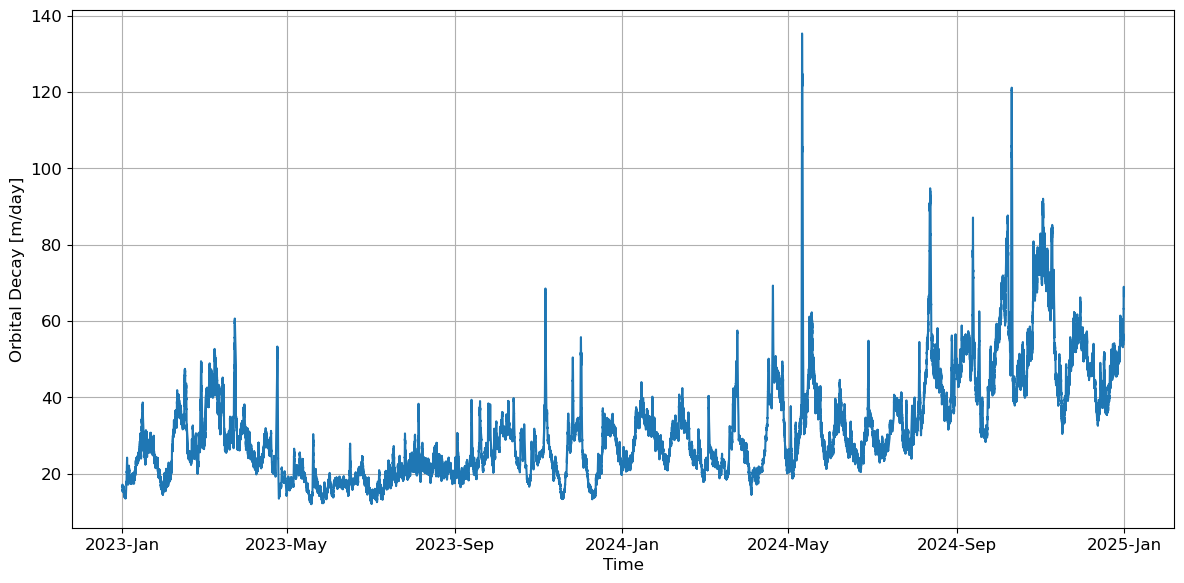

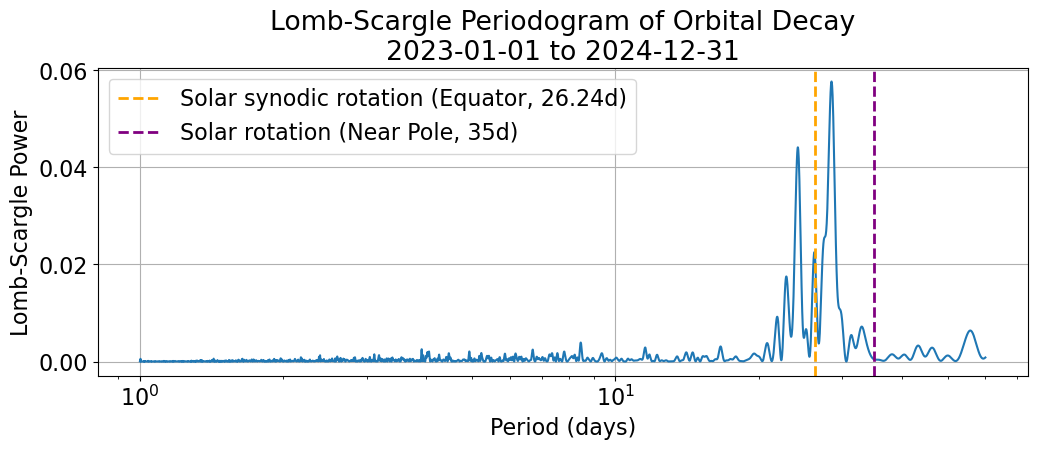

1. Period: 28.4865 +0.5337 -0.6549 days
2. Period: 24.1961 +0.3624 -0.3852 days
3. Period: 26.2105 +0.3189 -0.3137 days
4. Period: 22.8839 +0.3377 -0.2848 days
5. Period: 21.8937 +0.2318 -0.2608 days
6. Period: 32.9758 +0.8146 -0.7012 days
7. Period: 25.1786 +0.2418 -2.6944 days
8. Period: 55.7869 +1.7944 -1.8922 days
9. Period: 31.3493 +2.6288 -0.4007 days
10. Period: 8.4555 +0.0469 -0.0427 days


In [2]:
# =========================== Input ===================================
start_date = '2023-01-01 00:00:00'
end_date = '2025-01-01 00:00:00'

# Add an option for monthly, daily, or hourly ticks
tick_interval = 'monthly'  # Change to 'monthly', 'daily', or 'hourly'
tick_step = 4  # Step for the ticks (e.g., every month =1, every 2 months = 2, etc)

subset = GFOC_data.copy()
subset.set_index('time', inplace=True)
subset = create_subset2(subset, start_date, end_date, resample_rate='20s')
print(f"Selected date range: {start_date} to {end_date}")
print(f"Median decay rate: {subset['orbital_decay'].median():.4f} m/day")
print(f'Std decay rate: {subset["orbital_decay"].std():.4f} m/day')
print(f"Mean decay rate: {subset['orbital_decay'].mean():.4f} m/day")

plot_orbital_decay(GFOC_data, None, None, None, tick_interval, tick_step, FLAGS=False, Lombscargle=False)
plot_lombscargle_periodogram(GFOC_data, None, None,
    min_period=1.0,   # days
    max_period=60,  # days
    vlines=True,
    print_period='days',
    figsize=(12, 4),
    font_size=16,
    show=True
)

# Subsets

## Jan 23 to June 23

Selected date range: 2023-01-01 00:00:00 to 2023-06-01 00:00:00
Median decay rate: 24.7700 m/day
Std decay rate: 8.6208 m/day
Mean decay rate: 25.8825 m/day


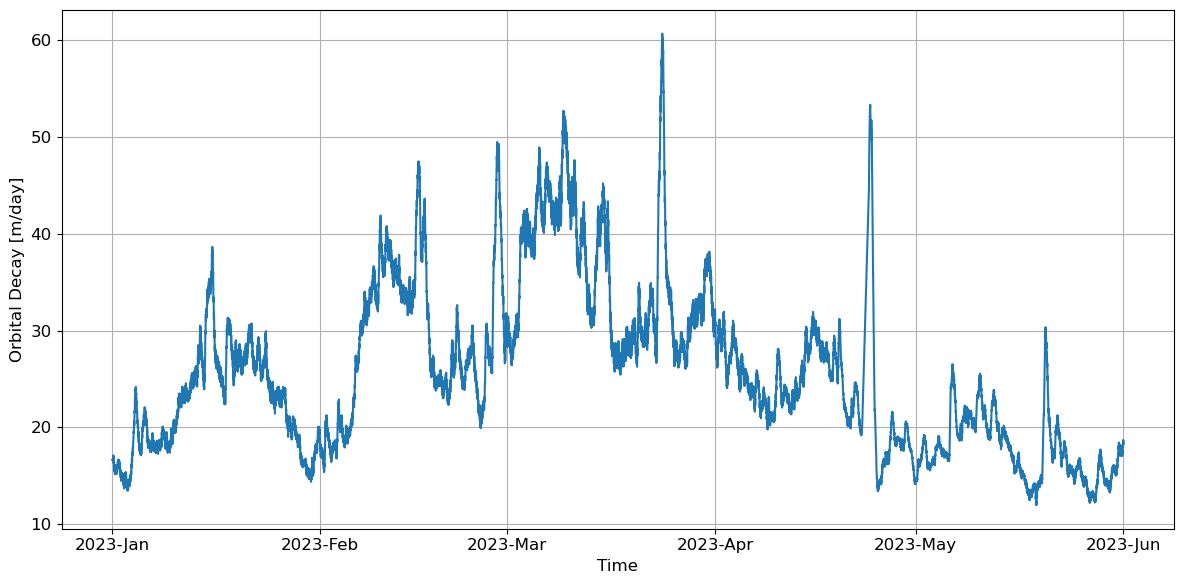

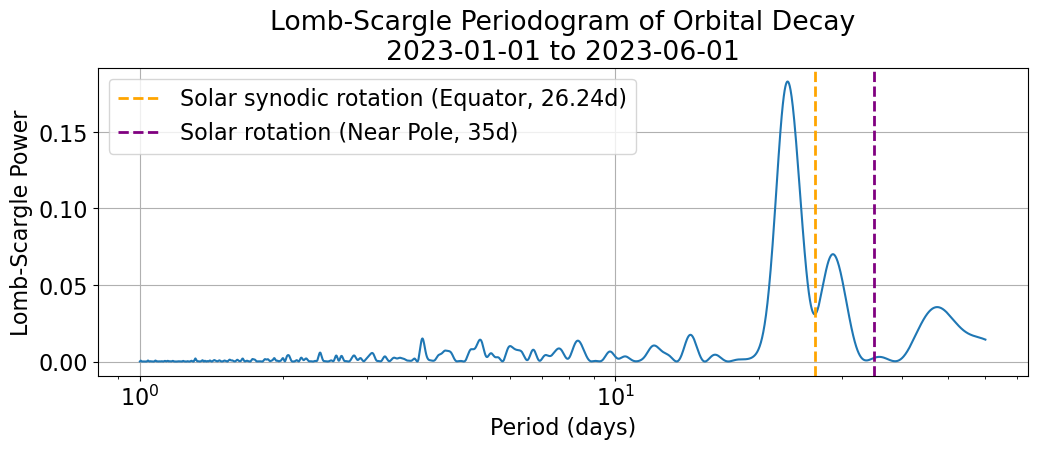

1. Period: 23.0238 +1.6850 -1.4460 days
2. Period: 28.6793 +2.0980 -1.9873 days
3. Period: 47.5006 +8.1350 -4.6261 days
4. Period: 14.3841 +0.4821 -0.4494 days
5. Period: 3.9276 +0.0547 -0.0457 days
6. Period: 5.1943 +0.1014 -0.2543 days
7. Period: 8.3377 +0.2624 -0.2294 days
8. Period: 12.0635 +0.6979 -0.4186 days
9. Period: 6.0075 +0.3871 -0.1193 days
10. Period: 7.6079 +0.1998 -0.2472 days


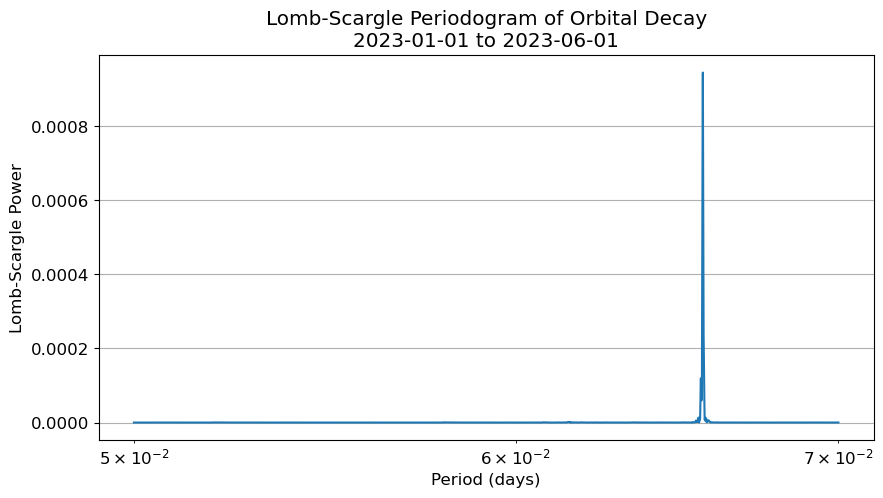

1. Period: 94.4803 +0.0233 -0.0230 minutes


In [ ]:
# =========================== Input ===================================
start_date = '2023-01-01 00:00:00'
end_date = '2023-06-01 00:00:00'

# Add an option for monthly, daily, or hourly ticks
tick_interval = 'monthly'  # Change to 'monthly', 'daily', or 'hourly'
tick_step = 1  # Step for the ticks (e.g., every month =1, every 2 months = 2, etc)

subset = GFOC_data.copy()
subset.set_index('time', inplace=True)
subset = create_subset2(subset, start_date, end_date, resample_rate='20s')
print(f"Selected date range: {start_date} to {end_date}")
print(f"Median decay rate: {subset['orbital_decay'].median():.4f} m/day")
print(f'Std decay rate: {subset["orbital_decay"].std():.4f} m/day')
print(f"Mean decay rate: {subset['orbital_decay'].mean():.4f} m/day")

plot_orbital_decay(GFOC_data, None, start_date, end_date, tick_interval, ticP
    min_period=1.0,   # days
    max_period=60,  # days
    vlines=True,
    print_period='days',
    figsize=(12, 4),
    font_size=16,
    show=True
)
plot_lombscargle_periodogram(GFOC_data, start_date, end_date,
    min_period=0.05,   # days
    max_period=0.07,  # days
    vlines=False,
    print_period='minutes',
    figsize=(10, 5),
    show=True
)

## June 23 to Oct 23

Selected date range: 2023-06-01 00:00:00 to 2023-10-01 00:00:00
Median decay rate: 20.4580 m/day
Std decay rate: 4.3127 m/day
Mean decay rate: 20.8452 m/day


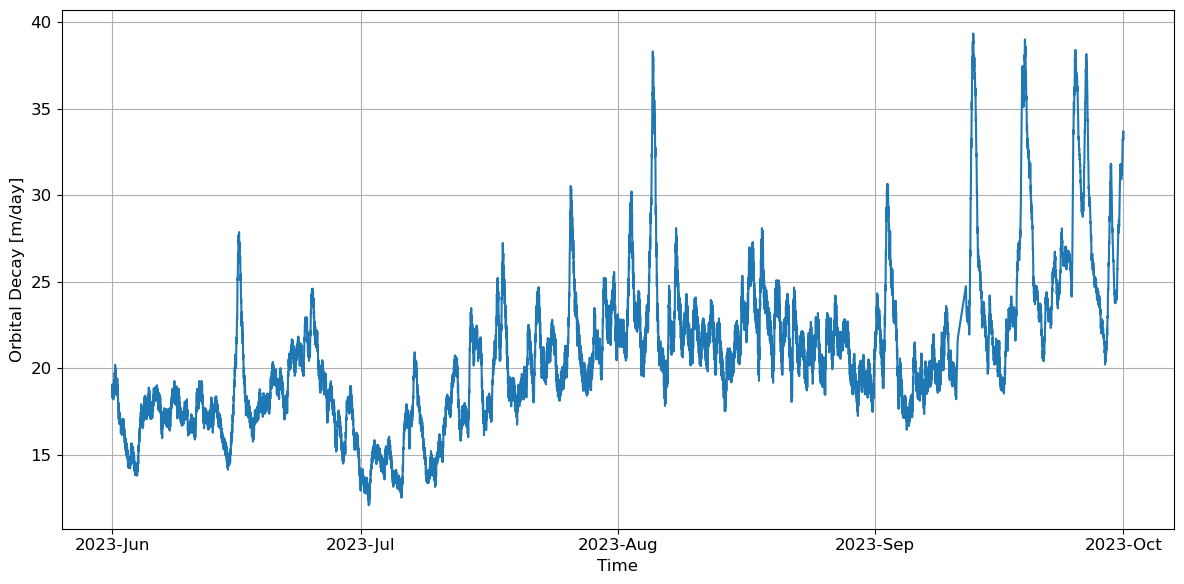

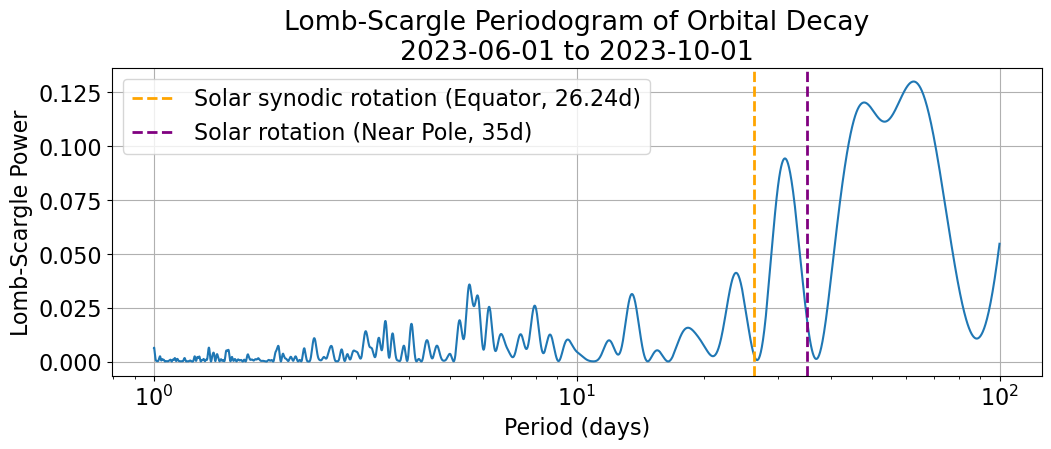

1. Period: 62.6572 +12.7684 -21.2785 days
2. Period: 47.8469 +28.2591 -6.7376 days
3. Period: 31.0789 +2.7562 -2.2939 days
4. Period: 23.8112 +1.4358 -1.3801 days
5. Period: 5.5726 +0.3502 -0.1112 days
6. Period: 13.5055 +0.5523 -0.5091 days
7. Period: 5.8215 +0.1137 -0.3728 days
8. Period: 7.9522 +0.2036 -0.2031 days
9. Period: 6.2037 +0.1208 -0.1104 days
10. Period: 5.2818 +0.6856 -0.0800 days


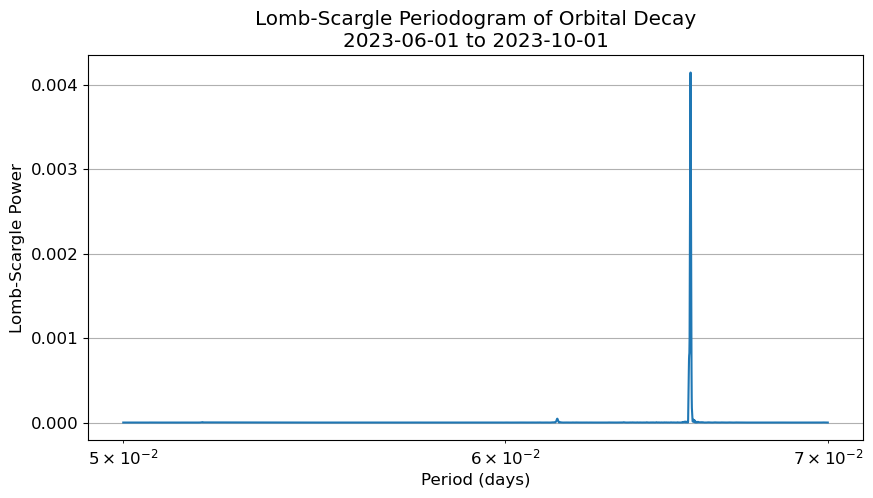

1. Period: 94.4053 +0.0267 -0.0279 minutes


In [4]:
# =========================== Input ===================================
start_date = '2023-06-01 00:00:00'
end_date = '2023-10-01 00:00:00'

# Add an option for monthly, daily, or hourly ticks
tick_interval = 'monthly'  # Change to 'monthly', 'daily', or 'hourly'
tick_step = 1  # Step for the ticks (e.g., every month =1, every 2 months = 2, etc)

subset = GFOC_data.copy()
subset.set_index('time', inplace=True)
subset = create_subset2(subset, start_date, end_date, resample_rate='20s')
print(f"Selected date range: {start_date} to {end_date}")
print(f"Median decay rate: {subset['orbital_decay'].median():.4f} m/day")
print(f'Std decay rate: {subset["orbital_decay"].std():.4f} m/day')
print(f"Mean decay rate: {subset['orbital_decay'].mean():.4f} m/day")

plot_orbital_decay(GFOC_data, None, start_date, end_date, tick_interval, tick_step, FLAGS=False, Lombscargle=False)
plot_lombscargle_periodogram(GFOC_data, start_date, end_date,
    min_period=1.0,   # days
    max_period=100,  # days
    vlines=True,
    print_period='days',
    figsize=(12, 4),
    font_size=16,
    show=True
)
plot_lombscargle_periodogram(GFOC_data, start_date, end_date,
    min_period=0.05,   # days
    max_period=0.07,  # days
    vlines=False,
    print_period='minutes',
    figsize=(10, 5),
    show=True
)

## Oct 23 Aug 24

Selected date range: 2023-10-01 00:00:00 to 2024-07-01 00:00:00
Median decay rate: 27.5755 m/day
Std decay rate: 9.3664 m/day
Mean decay rate: 29.0133 m/day


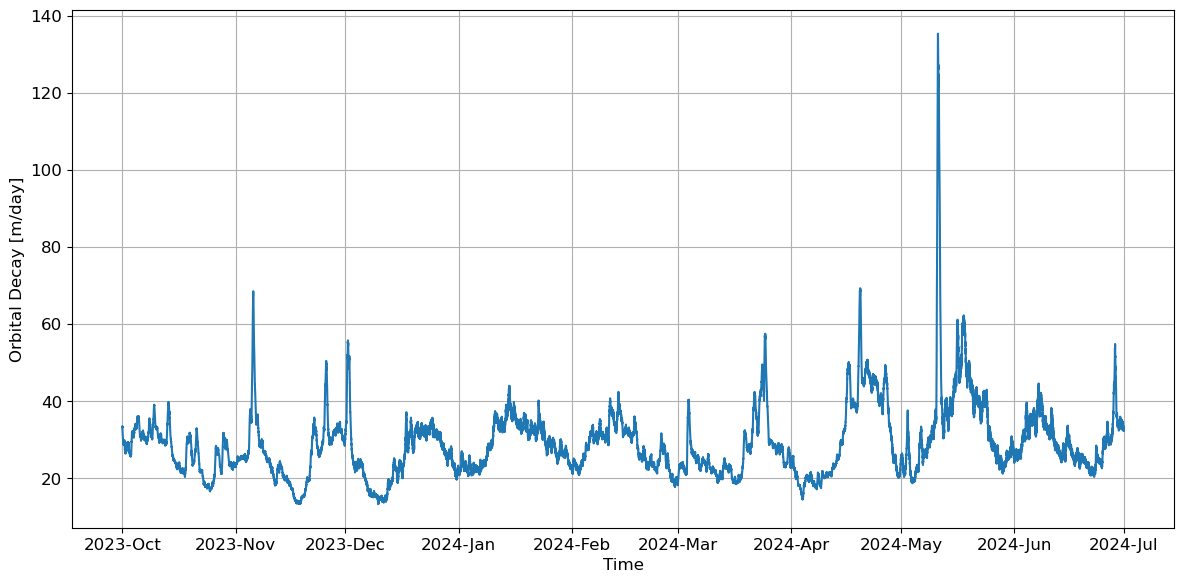

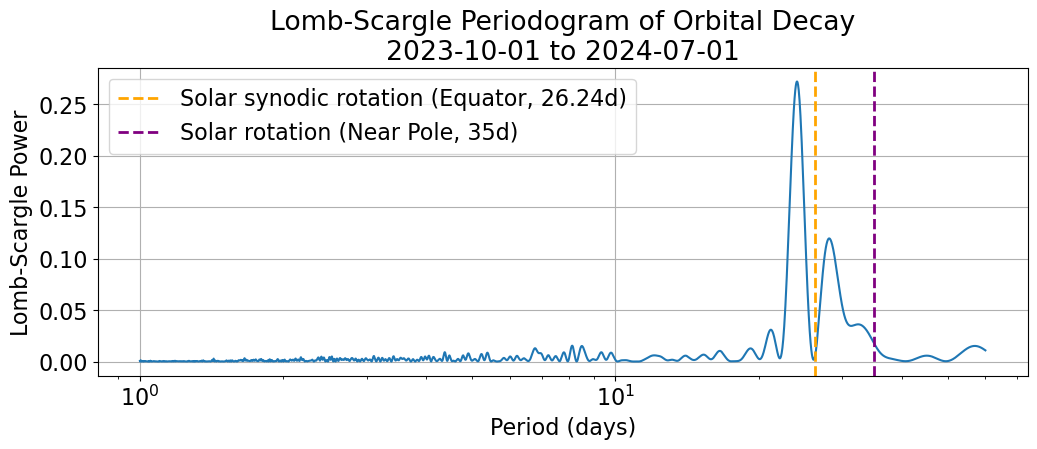

1. Period: 24.0987 +0.9204 -0.9227 days
2. Period: 28.1630 +1.6736 -1.1663 days
3. Period: 32.3980 +2.5654 -5.8730 days
4. Period: 21.2309 +0.5370 -0.5652 days
5. Period: 8.1122 +0.0865 -0.0864 days
6. Period: 57.0066 +2.9934 -3.8999 days
7. Period: 8.5015 +0.1487 -0.1143 days
8. Period: 6.7769 +0.2361 -0.1023 days
9. Period: 19.2387 +0.5191 -0.5412 days
10. Period: 16.5763 +0.4144 -0.4033 days


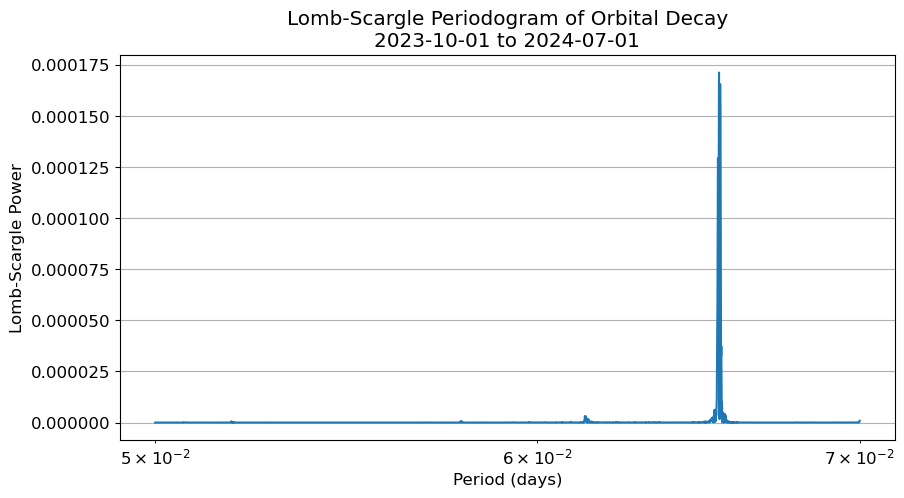

1. Period: 94.2517 +0.0118 -0.0613 minutes
2. Period: 94.3025 +0.0299 -0.0155 minutes


In [5]:
# =========================== Input ===================================
start_date = '2023-10-01 00:00:00'
end_date = '2024-07-01 00:00:00'

# Add an option for monthly, daily, or hourly ticks
tick_interval = 'monthly'  # Change to 'monthly', 'daily', or 'hourly'
tick_step = 1  # Step for the ticks (e.g., every month =1, every 2 months = 2, etc)

subset = GFOC_data.copy()
subset.set_index('time', inplace=True)
subset = create_subset2(subset, start_date, end_date, resample_rate='20s')
print(f"Selected date range: {start_date} to {end_date}")
print(f"Median decay rate: {subset['orbital_decay'].median():.4f} m/day")
print(f'Std decay rate: {subset["orbital_decay"].std():.4f} m/day')
print(f"Mean decay rate: {subset['orbital_decay'].mean():.4f} m/day")

plot_orbital_decay(GFOC_data, None, start_date, end_date, tick_interval, tick_step, FLAGS=False, Lombscargle=False)
plot_lombscargle_periodogram(GFOC_data, start_date, end_date,
    min_period=1.0,   # days
    max_period=60,  # days
    vlines=True,
    print_period='days',
    figsize=(12, 4),
    font_size=16,
    show=True
)
plot_lombscargle_periodogram(GFOC_data, start_date, end_date,
    min_period=0.05,   # days
    max_period=0.07,  # days
    vlines=False,
    print_period='minutes',
    figsize=(10, 5),
    show=True
)

## July 24 to Jan 25

Selected date range: 2024-07-01 00:00:00 to 2025-01-01 00:00:00
Median decay rate: 45.9830 m/day
Std decay rate: 14.2931 m/day
Mean decay rate: 47.3835 m/day


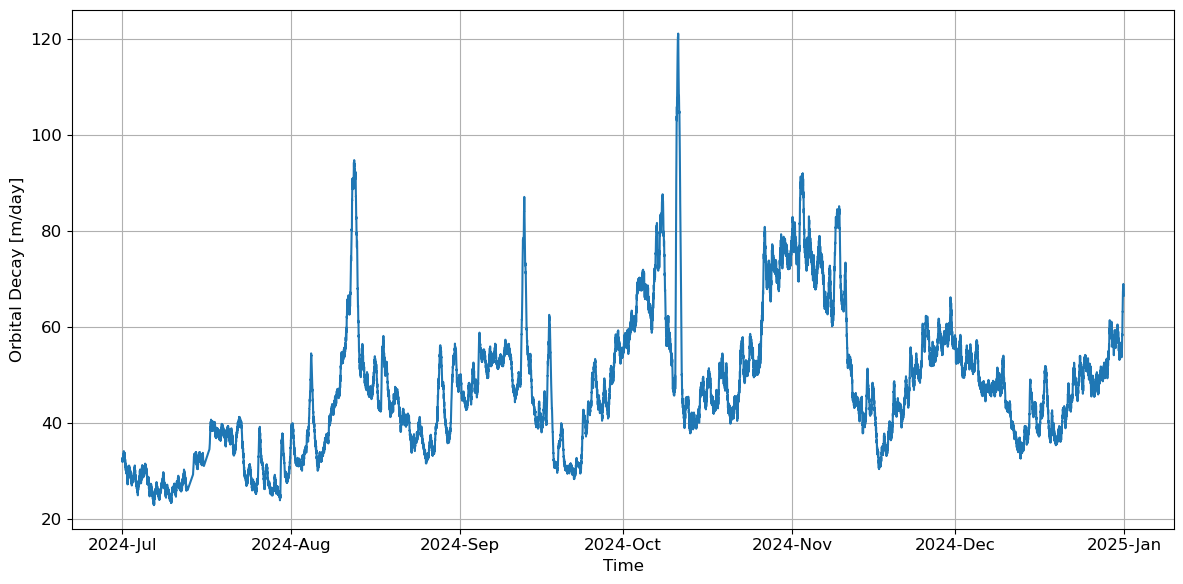

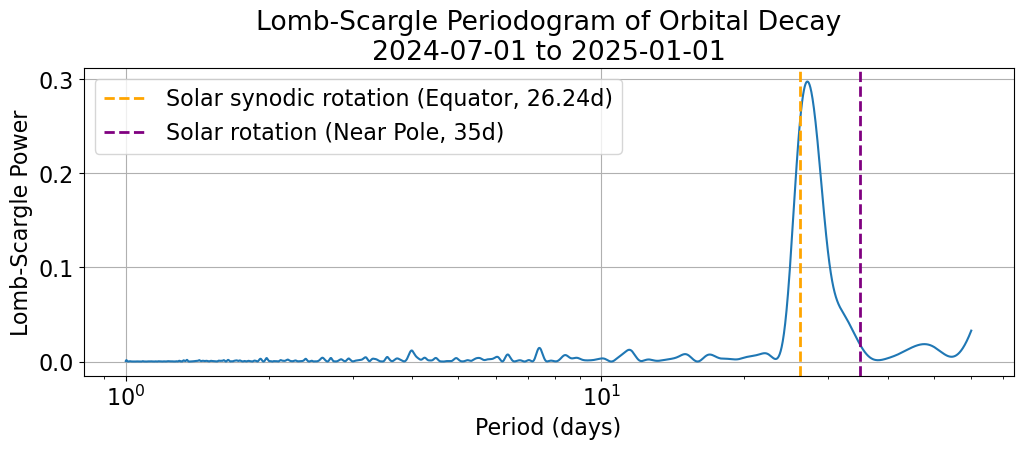

1. Period: 27.1336 +2.3879 -1.8297 days
2. Period: 47.8132 +4.3561 -5.0649 days
3. Period: 7.4105 +0.1256 -0.1180 days
4. Period: 11.4534 +0.3375 -0.4784 days
5. Period: 3.9926 +0.0795 -0.0637 days
6. Period: 22.0647 +0.8319 -1.9905 days
7. Period: 15.0060 +0.4721 -0.6807 days
8. Period: 6.3575 +0.0910 -0.0828 days
9. Period: 16.9126 +0.7714 -0.5154 days
10. Period: 8.4011 +0.2492 -0.1786 days


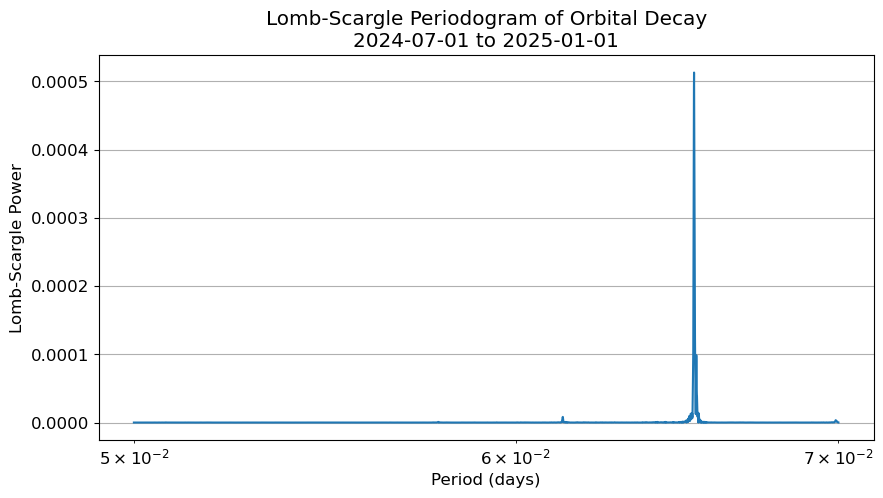

1. Period: 94.0849 +0.0277 -0.0221 minutes


In [6]:
# =========================== Input ===================================
start_date = '2024-07-01 00:00:00'
end_date = '2025-01-01 00:00:00'

# Add an option for monthly, daily, or hourly ticks
tick_interval = 'monthly'  # Change to 'monthly', 'daily', or 'hourly'
tick_step = 1  # Step for the ticks (e.g., every month =1, every 2 months = 2, etc)

subset = GFOC_data.copy()
subset.set_index('time', inplace=True)
subset = create_subset2(subset, start_date, end_date, resample_rate='20s')
print(f"Selected date range: {start_date} to {end_date}")
print(f"Median decay rate: {subset['orbital_decay'].median():.4f} m/day")
print(f'Std decay rate: {subset["orbital_decay"].std():.4f} m/day')
print(f"Mean decay rate: {subset['orbital_decay'].mean():.4f} m/day")

plot_orbital_decay(GFOC_data, None, start_date, end_date, tick_interval, tick_step, FLAGS=False, Lombscargle=False)
plot_lombscargle_periodogram(GFOC_data, start_date, end_date,
    min_period=1.0,   # days
    max_period=60,  # days
    vlines=True,
    print_period='days',
    figsize=(12, 4),
    font_size=16,
    show=True
)
plot_lombscargle_periodogram(GFOC_data, start_date, end_date,
    min_period=0.05,   # days
    max_period=0.07,  # days
    vlines=False,
    print_period='minutes',
    figsize=(10, 5),
    show=True
)